# Structure-based regression project

**Author:** [Albert J. Kooistra](https://drug.ku.dk/staff/?pure=en/persons/612712), 2023-2025, University of Copenhagen


**Main steps in this notebook/for the project**
- Getting to know our target - CDK2 - structure and interactions
- Collecting our data
- Classification - how to select the most probable binding pose?
- Feature selection and combination
- Regression - predicting the binding affinity of the CDK2 inhibitors
- Evaluation
- Prospective application => searching for gold!

From the predicted compounds with the highest affinity select top 3 candidates and create a poster for the final session!

## Installation and import of libraries and functions

Simply execute the code cells below to get started. 
Note the pip install might give you some minor errors, but you can ignore these.

In [1]:
# Installing missing libraries necessary for processing
!pip install -q rdkit prolif==1.1.0
!pip install -q py3Dmol

# Latest additions to process small molecules and calculate molecular features
!pip install -q datamol
!pip install -q molfeat

# Yellowbrick for visualizing Scikit-based machine learning models
!pip install -q yellowbrick

# Lightgbm and xgboost for gradient boosting
!pip install -q lightgbm
!pip install -q xgboost

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jupyter-ai 2.31.5 requires faiss-cpu!=1.8.0.post0,<2.0.0,>=1.8.0, which is not installed.
boto3 1.39.1 requires botocore<1.40.0,>=1.39.1, but you have botocore 1.40.70 which is incompatible.


In [2]:
# Import packages and libraries
import matplotlib.pyplot as plt
import MDAnalysis as mda
import numpy as np
import os
import pandas as pd
import prolif as plf
import py3Dmol
import re
import seaborn as sns

from ipywidgets import interact,fixed,IntSlider
from math import ceil
from rdkit import Chem
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split
from prolif.plotting.network import LigNetwork
from rdkit import Geometry

# Latest additions
import datamol as dm
from molfeat.calc import FPCalculator
from molfeat.trans import MoleculeTransformer
from yellowbrick.regressor import prediction_error, residuals_plot
from yellowbrick.datasets import load_energy
from yellowbrick.model_selection import LearningCurve
from yellowbrick.regressor import PredictionError

/opt/conda/lib/python3.12/site-packages/MDAnalysis/topology/tables.py:52: DeprecationWarning: Deprecated in version 2.8.0
MDAnalysis.topology.tables has been moved to MDAnalysis.guesser.tables. This import point will be removed in MDAnalysis version 3.0.0
  warnings.warn(wmsg, category=DeprecationWarning)


In [3]:
# Disabling warnings (can be tricky) - but RDkit can be "noisy"
import warnings
warnings.filterwarnings('ignore')

In [4]:
# HELPER FUNCTIONS
# No need to read the code or interpret

# Hover functions for the molecular viewer (Javascript code)
hover_func = """
  function(atom,viewer) {
    if (!atom.label) 
      atom.label = viewer.addLabel(atom.resn + " " + atom.resi,
      {position: atom, backgroundColor: 'black', fontColor:'white'});
  }"""

# Unhover function for the molecular viewer (Javascript code)
unhover_func = """function(atom,viewer) {if (atom.label) { viewer.removeLabel(atom.label); delete atom.label; }}"""

# proLIF - redefining HB-acceptors (slightly wider angle)
class HBAcceptor(plf.interactions.HBAcceptor):
   def __init__(self): 
     super().__init__(angles=(120, 180))

# proLIF - redefining HB-donors (slightly wider angle)
class HBDonor(plf.interactions.HBDonor):
   def __init__(self): 
      super().__init__(angles=(120, 180))

# Functions based on TeachOpenCADD - T007
# https://projects.volkamerlab.org/teachopencadd/index.html
def plot_roc_curves_for_models(score_column, data, save_png = False, negative_scores = True):
    """
    Helper function to plot customized roc curve.

    Parameters
    ----------
    score_column: string
        Name of the column with the scores
    data: dataframe
        Dataframe with two columns: <Score> and "Active"
    save_png: bool
        Save image to disk (default = False)
    negative_scores: bool
        Scores are inverted if lower scores are better

    Returns
    -------
    fig:
        Figure.
    """

    
    if negative_scores:
      data = data.copy()
      data[score_column] = -1 * data[score_column]

    fig, ax = plt.subplots()
    fig.set_dpi(100)

    # Compute ROC plot with False postive rate and True positive rate
    fpr, tpr, thresholds = roc_curve(data["Active"], data[score_column], pos_label=1)

    # Calculate Area under the curve to display on the plot
    auc = roc_auc_score(data["Active"], data[score_column])

    # Plot the computed values
    ax.plot(fpr, tpr, label=(f"{score_column} AUROC = {auc:.2f}"))

    # Custom settings for the plot
    ax.plot([0, 1], [0, 1], "r--")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("Receiver Operating Characteristic")
    ax.legend(loc="lower right")

    # Save plot
    if save_png:
        fig.savefig(f"{DATA}/roc_auc", dpi=300, bbox_inches="tight", transparent=True)

    return fig

# Based on example from https://gist.github.com/ravila4/
def EF_method2(actives_list, score_list, n_percent = 1, positive_scores = False):
    """ Calculates enrichment factor (method 2)
    Parameters:
    actives_list - binary array of active/decoy status
    score_list - array of experimental scores
    n_percent - a percentage (default 1%)
    positive_scores - set to True if a higher score is better (default False)
    """

    # Count active and inactive compounds
    total_actives = len(actives_list[actives_list == 1])
    total_inactives = len(actives_list) - total_actives

    # Sort scores, while keeping track of active/decoy status
    labeled_hits = sorted(zip(score_list, actives_list), reverse=positive_scores)

    # Get position (index) of the inactive compound at n_percent FP-rate
    num_fp = ceil(n_percent/100 * total_inactives)
    # Get positions all inactive compounds and select the num_fp one
    pos_fps = [i for i, labeled in enumerate(labeled_hits) if labeled[1] == 0][num_fp]

    # Get number of actives at this position
    identified_actives = sum([labeled[1] for labeled in labeled_hits[:num_fp]])

    # Calculate enrichment factor (TP-rate / FP-rate)
    ef = (identified_actives/total_actives) / (n_percent/100)
    return round(ef,2)

## Cyclin-dependent kinase 2

Our protein target for this project is *CDK2*, also known as *cyclin-dependent kinase 2* or *cell division protein kinase 2*.

CDK2 is a protein kinase that is critical for regulating cell cycle progression by complexing with and phosphorylation of key targets involved in the transition from G1 to S phase. In addition, it is involved in DNA replication, transcription, and repair. 

As input we have:
* Known binding modes and affinities of CDK2 inhibitors from >200 crystal structures
* Known experimentally determined binding affinities of >2K CDK2 inhibitors
* A set of >10K virtual compounds constructed using a kinase fragment library

### Collecting and processing the data

Below we will download the dataset and extract it.
The files will be in your Noteable home folder under *final_project*.

If you would like to download the files to your own computers you can do so here:
https://www.dropbox.com/s/4ajdpj63qhyur3m/Week_6_dataset.tgz?dl=0

In [5]:
# Getting the full data package and extract
# Only do this if we don't already have it!
%cd ~/
if not os.path.isfile("final_project/Week_6_dataset.tgz"):
    ! mkdir final_project 2>/dev/null
    %cd ~/final_project
    
    # Downloading the dataset
    ! wget -q --show-progress "https://www.dropbox.com/s/4ajdpj63qhyur3m/Week_6_dataset.tgz?dl=1" -O Week_6_dataset.tgz
    
    # Extracting the dataset
    ! tar -xvzf Week_6_dataset.tgz 2>/dev/null
else:
    %cd ~/final_project

/home/jovyan
/home/jovyan/final_project


### The data

We have three folders: *4nj3_docked* and *5k4j_docked*, and a *smiles* folder.
In these folders we have the processed docking results for docking in the 4NJ3 and 5K4J structures.

Docking scoring results: 
* chembl_features.csv.gz - docking scores and features for the ChEMBL CDK2 inhibitors
* xrays_features.csv.gz - docking scores and features for the redocked CDK2 inhibitors from the crystal structures
* prospective_features.csv.gz - docking scores and features for the virtual compounds

Interaction fingerprint results:
* chembl_ifp.csv.gz - Interactions for the docking poses of the ChEMBL CDK2 inhibitors
* xrays_ifp.csv.gz - Interactions for the docking poses of the redocked CDK2 inhibitors from the crystal structures
* prospective_ifp.csv.gz - Interactions for the docking poses of the virtual compounds

The results from the redocking:
* xrays_rmsd.csv.gz - RMSD for each docking pose of the redocked ligands from the CDK2 crystal structures

The unprepared reference structures:
* protein.pdb - the CDK2 protein structure
* ligand.pdb - the ligand in the CDK2 structure

And finally in the smiles folder, we have the chemical structure for all of the compounds:
* chembl.smi - The compounds in the ChEMBL CDK2 dataset
* xrays.smi - The compounds in the CDK2 crystal structures we use for redocking and pose prediction
* prospective.smi - The virtual kinase compound library for prospective application at the end of the project

### Reading the docking scores and ifp from docking in the 4NJ3 protein structure

Check the contents of all dataframes to be sure everything is in order and familiarize yourself with the data.

In [6]:
# Reading in the docking scores and ifp from docking the 4NJ3 protein structure
chembl_feats_4nj3 = pd.read_csv("4nj3_docked/chembl_features.csv.gz")
xrays_feats_4nj3 = pd.read_csv("4nj3_docked/xrays_features.csv.gz")
chembl_ifps_4nj3 = pd.read_csv("4nj3_docked/chembl_ifp.csv.gz")
xrays_ifps_4nj3 = pd.read_csv("4nj3_docked/xrays_ifp.csv.gz")
rmsd_4nj3 = pd.read_csv("4nj3_docked/xrays_rmsd.csv.gz")

In [7]:
# TODO: CHECK THE DATA
rmsd_4nj3

,RMSD
LZM|4283|2vtm_chainA|3.0_entry_00001_conf_01,4.501887
LZM|4283|2vtm_chainA|3.0_entry_00001_conf_02,1.177360
LZM|4283|2vtm_chainA|3.0_entry_00001_conf_03,3.840978
LZM|4283|2vtm_chainA|3.0_entry_00001_conf_04,4.566930
LZM|4283|2vtm_chainA|3.0_entry_00001_conf_05,2.628785
...,...
CDK|3985|2xmy_altB_chainA|9.96_entry_00216_conf_06,6.285726
CDK|3985|2xmy_altB_chainA|9.96_entry_00216_conf_07,9.975007
CDK|3985|2xmy_altB_chainA|9.96_entry_00216_conf_08,11.276511
CDK|3985|2xmy_altB_chainA|9.96_entry_00216_conf_09,14.721522


### Reading the docking scores and ifp from docking in the 5K4J protein structure

Check the contents of all dataframes to be sure everything is in order and familiarize yourself with the data.

In [8]:
# Reading in the docking scores and ifp from docking the 5K4J protein structure
chembl_feats_5k4j = pd.read_csv("5k4j_docked/chembl_features.csv.gz")
xrays_feats_5k4j = pd.read_csv("5k4j_docked/xrays_features.csv.gz")
chembl_ifps_5k4j = pd.read_csv("5k4j_docked/chembl_ifp.csv.gz")
xrays_ifps_5k4j = pd.read_csv("5k4j_docked/xrays_ifp.csv.gz")
rmsd_5k4j = pd.read_csv("5k4j_docked/xrays_rmsd.csv.gz")

In [9]:
# TODO: CHECK THE DATA
rmsd_5k4j

,RMSD
LZM|4283|2vtm_chainA|3.0_entry_00001_conf_01,4.483202
LZM|4283|2vtm_chainA|3.0_entry_00001_conf_02,1.173069
LZM|4283|2vtm_chainA|3.0_entry_00001_conf_03,3.545454
LZM|4283|2vtm_chainA|3.0_entry_00001_conf_04,2.624674
LZM|4283|2vtm_chainA|3.0_entry_00001_conf_05,4.415072
...,...
CDK|3985|2xmy_altB_chainA|9.96_entry_00216_conf_06,8.548091
CDK|3985|2xmy_altB_chainA|9.96_entry_00216_conf_07,10.600836
CDK|3985|2xmy_altB_chainA|9.96_entry_00216_conf_08,6.252801
CDK|3985|2xmy_altB_chainA|9.96_entry_00216_conf_09,5.500353


In [10]:
# Create a py3Dmol viewer
view = py3Dmol.view()

# Read the protein and show it as a slightly transparent gold cartoon
view.addModel(open("4nj3_docked/protein.pdb","r").read(), format="pdb")
prot = view.getModel()
prot.setStyle({"cartoon" : {"color" : "gold", "opacity": 0.6}})

# Read the ligand file and add the ligand 
prot.addMolData(open("4nj3_docked/ligand.pdb","r").read(), format="pdb")

# Add a hover/unhover functions to get some information about the residues and atoms
view.setHoverable({}, True, hover_func, unhover_func)

### SELECTING the binding site residues within 5 angstrom of the ligand
pocket_selection = {"hetflag": True, "byres": "true", "expand": 5}

# Color the binding site residues in gold
view.addStyle(pocket_selection, {"stick" : {"colorscheme": "goldCarbon"}})

# Revert coloring of the ligand back to cyan
view.addStyle({"hetflag": True}, {"stick":{"colorscheme" : "cyanCarbon"}})

# Zoom into the binding site and show it!
view.zoomTo(pocket_selection)
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Structure inspection and protein-ligand interactions

Atomistic insights into the CDK2 protein targets and its inhibitors!

**TODO:**
* Adjust the files read above to read the 5k4j protein and ligand (instead of the 4NJ3)
* Execute the code and inspect the pocket and binding of the ligand to CDK2
* What are the main differences between the two structures?

In [11]:
# Create a py3Dmol viewer
view = py3Dmol.view()

# Read the protein and show it as a slightly transparent gold cartoon
view.addModel(open("5k4j_docked/protein.pdb","r").read(), format="pdb")
prot = view.getModel()
prot.setStyle({"cartoon" : {"color" : "gold", "opacity": 0.6}})

# Read the ligand file and add the ligand 
prot.addMolData(open("5k4j_docked/ligand.pdb","r").read(), format="pdb")

# Add a hover/unhover functions to get some information about the residues and atoms
view.setHoverable({}, True, hover_func, unhover_func)

### SELECTING the binding site residues within 5 angstrom of the ligand
pocket_selection = {"hetflag": True, "byres": "true", "expand": 5}

# Color the binding site residues in gold
view.addStyle(pocket_selection, {"stick" : {"colorscheme": "goldCarbon"}})

# Revert coloring of the ligand back to cyan
view.addStyle({"hetflag": True}, {"stick":{"colorscheme" : "cyanCarbon"}})

# Zoom into the binding site and show it!
view.zoomTo(pocket_selection)
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Classification step - selecting the right pose

A crucial step in assessing a docking is the selection of the right docking pose. Using information from >200 crystal structures we will try to optimize the pose selection here by creating a pose classifier.

**Steps**:
* Select optimal binding modes using the RMSD (precalculated)
* Evaluating the features from docking into the crystal structures
* OPTIONAL: extending with a classifier method from last weeks notebook

First we need to combine the features with the RMSD to get an accurate data set. Below is an example for solely the docking into the 4NJ3 structure.

**QUICK recap**

The features.csv file contains a several different docking scoring elements, i.e. different docking scoring features. A list from the PLANTS manual is listed below.

*	PLPparthbond: PLP hbond score
*	PLPpartsteric: PLP steric contact score
*	PLPpartmetal: PLP metal interaction score
*	PLPpartrepulsive: PLP donor/donor and acceptor/acceptor repulsion score
*	PLPpartburpolar: PLP buried polar atoms score (polar atoms occluded by nonpolar ones)
*	LIG_NUM_CLASH: number of ligand atoms with PLP score greater zero
*	LIG_NUM_CONTACT: number of ligand atoms with attractive PLP score
*	LIG_NUM_NO_CONTACT: number of ligand atoms with zero PLP score
*	CHEMpartmetal: CHEMSCORE metal interaction score
*	CHEMparthbond: CHEMSCORE hbond score
*	DON: number of ligand donor atoms
*	ACC: number of ligand acceptor atoms
*	UNUSED_DON: number of unpaired ligand donors
*	UNUSED_ACC: number of unpaired ligand acceptors
*	CHEMPLP_CLASH: intra-ligand clash score
*	TRIPOS_TORS: intra-ligand torsion score
*	INTRAPROT_CHEMPLP_PLP: intra-protein score (only calculated for flex. side-chains)
*	ATOMS_OUTSIDE_BINDINGSITE: number of ligand atoms outside binding site


In [12]:
# DATA we read in earlier for 4NJ3
# xrays_feats_4nj3 - features from docking
# xrays_ifps_4nj3 - IFPs from the docking poses = pd.read_csv("5k4j_docked/xrays_ifp.csv.gz")
# rmsd_4nj3 - RMSDs for the dockign poses compared to the crystal structures

# Combining the features with the RMSD
merged_rmsd = xrays_feats_4nj3.merge(rmsd_4nj3, left_index=True, right_index=True)
merged_rmsd.head()

,TOTAL_SCORE,SCORE_RB_PEN,SCORE_NORM_HEVATOMS,SCORE_NORM_CRT_HEVATOMS,SCORE_NORM_WEIGHT,SCORE_NORM_CRT_WEIGHT,SCORE_RB_PEN_NORM_CRT_HEVATOMS,SCORE_NORM_CONTACT,PLPtotal,PLPparthbond,...,CHEMparthbond,CHEMparthbondCHO,DON,ACC,UNUSED_DON,UNUSED_ACC,CHEMPLP_CLASH2,TRIPOS_TORS,ATOMS_OUTSIDE_BINDINGSITE,RMSD
LZM|4283|2vtm_chainA|3.0_entry_00001_conf_01,-57.0043,-55.0043,-5.18221,-25.6316,-0.395473,-10.8720,-24.7324,-4.75036,-31.0932,-1.000000,...,-3.00000,-2.99436,2,3,1,2,0.0,0.0,0,4.501887
LZM|4283|2vtm_chainA|3.0_entry_00001_conf_02,-56.0737,-54.0737,-5.09761,-25.2132,-0.389017,-10.6946,-24.3139,-4.67281,-30.8897,-0.983832,...,-2.99829,-3.00000,2,3,1,2,0.0,0.0,0,1.177360
LZM|4283|2vtm_chainA|3.0_entry_00001_conf_03,-55.2158,-53.2158,-5.01962,-24.8275,-0.383066,-10.5309,-23.9282,-4.60132,-29.9326,-1.000000,...,-3.00000,-3.00000,2,3,1,2,0.0,0.0,0,3.840978
LZM|4283|2vtm_chainA|3.0_entry_00001_conf_04,-54.9417,-52.9417,-4.99470,-24.7042,-0.381164,-10.4787,-23.8049,-4.99470,-32.6245,-1.000000,...,-3.00000,0.00000,2,3,2,2,0.0,0.0,0,4.566930
LZM|4283|2vtm_chainA|3.0_entry_00001_conf_05,-54.5830,-52.5830,-4.96209,-24.5430,-0.378675,-10.4102,-23.6437,-4.96209,-32.0638,-1.000000,...,-3.00000,0.00000,2,3,2,2,0.0,0.0,0,2.628785


Currently, the RMSD is a numerical value - but we want to discern between good/bad.\
By using cutoffs for good and bad poses, we can convert this into a classification problem!

In the example below we assume that all poses predicted with an RMSD ≤ 2.5 are good and RMSD ≥ 4.0 are bad.

In [13]:
# First we only keep values in the good and bad range (making a copy of the data)
pose_filtered = merged_rmsd[ (merged_rmsd["RMSD"] <= 2.5) | (merged_rmsd["RMSD"]>= 4.0) ].copy()
pose_filtered

,TOTAL_SCORE,SCORE_RB_PEN,SCORE_NORM_HEVATOMS,SCORE_NORM_CRT_HEVATOMS,SCORE_NORM_WEIGHT,SCORE_NORM_CRT_WEIGHT,SCORE_RB_PEN_NORM_CRT_HEVATOMS,SCORE_NORM_CONTACT,PLPtotal,PLPparthbond,...,CHEMparthbond,CHEMparthbondCHO,DON,ACC,UNUSED_DON,UNUSED_ACC,CHEMPLP_CLASH2,TRIPOS_TORS,ATOMS_OUTSIDE_BINDINGSITE,RMSD
LZM|4283|2vtm_chainA|3.0_entry_00001_conf_01,-57.0043,-55.0043,-5.18221,-25.6316,-0.395473,-10.87200,-24.7324,-4.75036,-31.0932,-1.000000,...,-3.00000,-2.99436,2,3,1,2,0.000000,0.00000,0,4.501887
LZM|4283|2vtm_chainA|3.0_entry_00001_conf_02,-56.0737,-54.0737,-5.09761,-25.2132,-0.389017,-10.69460,-24.3139,-4.67281,-30.8897,-0.983832,...,-2.99829,-3.00000,2,3,1,2,0.000000,0.00000,0,1.177360
LZM|4283|2vtm_chainA|3.0_entry_00001_conf_04,-54.9417,-52.9417,-4.99470,-24.7042,-0.381164,-10.47870,-23.8049,-4.99470,-32.6245,-1.000000,...,-3.00000,0.00000,2,3,2,2,0.000000,0.00000,0,4.566930
LZM|4283|2vtm_chainA|3.0_entry_00001_conf_06,-54.4318,-52.4318,-4.94835,-24.4750,-0.377626,-10.38140,-23.5757,-4.53598,-29.7930,-1.000000,...,-2.99679,-3.00000,2,3,1,2,0.000000,0.00000,0,1.973927
LZM|4283|2vtm_chainA|3.0_entry_00001_conf_07,-53.5999,-51.5999,-4.87272,-24.1009,-0.371855,-10.22270,-23.2016,-4.46666,-29.2157,-0.979506,...,-2.29959,-3.00000,2,3,1,2,0.000000,0.00000,0,5.251526
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CDK|3985|2xmy_altB_chainA|9.96_entry_00216_conf_05,-77.6150,-61.6150,-2.67638,-25.2627,-0.178213,-10.23950,-20.0549,-2.58717,-65.2685,-2.397350,...,-6.98454,0.00000,3,6,2,4,0.062614,5.96442,1,7.327789
CDK|3985|2xmy_altB_chainA|9.96_entry_00216_conf_06,-75.7634,-59.7634,-2.61253,-24.6600,-0.173962,-9.99518,-19.4522,-2.44398,-61.9004,-1.861170,...,-6.00000,-3.00000,3,6,1,5,0.225788,6.10933,1,6.285726
CDK|3985|2xmy_altB_chainA|9.96_entry_00216_conf_07,-75.5073,-59.5073,-2.60370,-24.5767,-0.173374,-9.96139,-19.3689,-2.43572,-56.7607,-2.000000,...,-6.00000,-3.00000,3,6,1,5,0.000000,4.79229,0,9.975007
CDK|3985|2xmy_altB_chainA|9.96_entry_00216_conf_08,-75.3920,-59.3920,-2.59972,-24.5391,-0.173109,-9.94618,-19.3313,-2.51307,-57.7345,-4.976740,...,-10.44300,0.00000,3,6,2,3,0.000000,5.46990,2,11.276511


In [14]:
# Convert RMSD into Good/Bad
pose_filtered["RMSD"][pose_filtered["RMSD"] <= 2.5] = True
pose_filtered["RMSD"][pose_filtered["RMSD"] >= 4.0] = False

# Convert type also to boolean
pose_filtered["RMSD"] = pose_filtered["RMSD"].astype('bool')

pose_filtered

,TOTAL_SCORE,SCORE_RB_PEN,SCORE_NORM_HEVATOMS,SCORE_NORM_CRT_HEVATOMS,SCORE_NORM_WEIGHT,SCORE_NORM_CRT_WEIGHT,SCORE_RB_PEN_NORM_CRT_HEVATOMS,SCORE_NORM_CONTACT,PLPtotal,PLPparthbond,...,CHEMparthbond,CHEMparthbondCHO,DON,ACC,UNUSED_DON,UNUSED_ACC,CHEMPLP_CLASH2,TRIPOS_TORS,ATOMS_OUTSIDE_BINDINGSITE,RMSD
LZM|4283|2vtm_chainA|3.0_entry_00001_conf_01,-57.0043,-55.0043,-5.18221,-25.6316,-0.395473,-10.87200,-24.7324,-4.75036,-31.0932,-1.000000,...,-3.00000,-2.99436,2,3,1,2,0.000000,0.00000,0,False
LZM|4283|2vtm_chainA|3.0_entry_00001_conf_02,-56.0737,-54.0737,-5.09761,-25.2132,-0.389017,-10.69460,-24.3139,-4.67281,-30.8897,-0.983832,...,-2.99829,-3.00000,2,3,1,2,0.000000,0.00000,0,True
LZM|4283|2vtm_chainA|3.0_entry_00001_conf_04,-54.9417,-52.9417,-4.99470,-24.7042,-0.381164,-10.47870,-23.8049,-4.99470,-32.6245,-1.000000,...,-3.00000,0.00000,2,3,2,2,0.000000,0.00000,0,False
LZM|4283|2vtm_chainA|3.0_entry_00001_conf_06,-54.4318,-52.4318,-4.94835,-24.4750,-0.377626,-10.38140,-23.5757,-4.53598,-29.7930,-1.000000,...,-2.99679,-3.00000,2,3,1,2,0.000000,0.00000,0,True
LZM|4283|2vtm_chainA|3.0_entry_00001_conf_07,-53.5999,-51.5999,-4.87272,-24.1009,-0.371855,-10.22270,-23.2016,-4.46666,-29.2157,-0.979506,...,-2.29959,-3.00000,2,3,1,2,0.000000,0.00000,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CDK|3985|2xmy_altB_chainA|9.96_entry_00216_conf_05,-77.6150,-61.6150,-2.67638,-25.2627,-0.178213,-10.23950,-20.0549,-2.58717,-65.2685,-2.397350,...,-6.98454,0.00000,3,6,2,4,0.062614,5.96442,1,False
CDK|3985|2xmy_altB_chainA|9.96_entry_00216_conf_06,-75.7634,-59.7634,-2.61253,-24.6600,-0.173962,-9.99518,-19.4522,-2.44398,-61.9004,-1.861170,...,-6.00000,-3.00000,3,6,1,5,0.225788,6.10933,1,False
CDK|3985|2xmy_altB_chainA|9.96_entry_00216_conf_07,-75.5073,-59.5073,-2.60370,-24.5767,-0.173374,-9.96139,-19.3689,-2.43572,-56.7607,-2.000000,...,-6.00000,-3.00000,3,6,1,5,0.000000,4.79229,0,False
CDK|3985|2xmy_altB_chainA|9.96_entry_00216_conf_08,-75.3920,-59.3920,-2.59972,-24.5391,-0.173109,-9.94618,-19.3313,-2.51307,-57.7345,-4.976740,...,-10.44300,0.00000,3,6,2,3,0.000000,5.46990,2,False


Now we have our data, and are ready to evaluate which feature best corrrelates with the correct pose selection!

In [15]:
# Select names of the columns in our dataset
colnames = pose_filtered.columns.values.tolist()

# Remove "RMSD" from the names
colnames = colnames[ : -1]

# Loop over the column names in our dataset
for colname in colnames:
    # Check if the column has only positive numbers or not
    # This is to invert the evalution of the score if it only contains positive
    only_positive = (pose_filtered[colname] < 0).sum().sum() == 0
    
    # Assess predictive power of this column for pose selection using the AUROC
    if only_positive:
        auc = roc_auc_score(pose_filtered["RMSD"], pose_filtered[colname])
    else:
        auc = roc_auc_score(pose_filtered["RMSD"], -1 * pose_filtered[colname])
        
    # Also take the enrichment factor into account at 1% FP-rate
    ef1 = EF_method2(pose_filtered["RMSD"], pose_filtered[colname], 1, only_positive)
    print(f"{colname} has an AUROC of {round(auc,2)} and EF1 of {round(ef1,2)}")

TOTAL_SCORE has an AUROC of 0.49 and EF1 of 1.78
SCORE_RB_PEN has an AUROC of 0.51 and EF1 of 2.07
SCORE_NORM_HEVATOMS has an AUROC of 0.64 and EF1 of 1.48
SCORE_NORM_CRT_HEVATOMS has an AUROC of 0.56 and EF1 of 2.96
SCORE_NORM_WEIGHT has an AUROC of 0.62 and EF1 of 1.18
SCORE_NORM_CRT_WEIGHT has an AUROC of 0.55 and EF1 of 3.25
SCORE_RB_PEN_NORM_CRT_HEVATOMS has an AUROC of 0.59 and EF1 of 3.55
SCORE_NORM_CONTACT has an AUROC of 0.61 and EF1 of 0.3
PLPtotal has an AUROC of 0.49 and EF1 of 1.18
PLPparthbond has an AUROC of 0.47 and EF1 of 0.0
PLPpartsteric has an AUROC of 0.51 and EF1 of 0.59
PLPpartmetal has an AUROC of 0.5 and EF1 of 4.14
PLPpartrepulsive has an AUROC of 0.44 and EF1 of 0.3
PLPpartburpolar has an AUROC of 0.46 and EF1 of 0.0
LIG_NUM_CLASH has an AUROC of 0.46 and EF1 of 0.0
LIG_NUM_CONTACT has an AUROC of 0.4 and EF1 of 0.3
LIG_NUM_NO_CONTACT has an AUROC of 0.5 and EF1 of 2.96
CHEMpartmetal has an AUROC of 0.5 and EF1 of 4.14
CHEMparthbond has an AUROC of 0.54 and E

As we can see above, the features are not doing so well. So this could be a point for optimization!
We also made an assumption based on the RMSD, but this also means we can have multiple "correct" poses per ligand. Something to consider

For now, we will just use the "SCORE_RB_PEN_NORM_CRT_HEVATOMS" for the pose selection and continue.

### Regression preparation

Preparing our data

In [16]:
# In this example, we will continue with just the 4NJ3 results both IFP and docking features

feat_all = chembl_feats_4nj3.merge(chembl_ifps_4nj3, left_index=True, right_index=True)
feat_all

,TOTAL_SCORE,SCORE_RB_PEN,SCORE_NORM_HEVATOMS,SCORE_NORM_CRT_HEVATOMS,SCORE_NORM_WEIGHT,SCORE_NORM_CRT_WEIGHT,SCORE_RB_PEN_NORM_CRT_HEVATOMS,SCORE_NORM_CONTACT,PLPtotal,PLPparthbond,...,THR165.A_HBDonor,THR165.A_HBAcceptor,THR165.A_VdWContact,LEU296.A_VdWContact,ARG297.A_HBDonor,ARG297.A_VdWContact,LEU298.A_Hydrophobic,LEU298.A_HBDonor,LEU298.A_Cationic,LEU298.A_VdWContact
CHEMBL100391|6.3_entry_00001_conf_01,-91.3864,-71.3864,-3.15126,-29.7451,-0.220256,-12.2527,-23.2354,-2.85583,-69.7650,-4.40947,...,0,0,0,0,0,0,0,0,0,0
CHEMBL100391|6.3_entry_00001_conf_02,-90.9380,-70.9380,-3.13579,-29.5992,-0.219175,-12.1925,-23.0894,-2.75570,-68.3340,-3.75500,...,0,0,0,0,0,0,0,0,0,0
CHEMBL100391|6.3_entry_00001_conf_03,-89.4493,-69.4493,-3.08446,-29.1146,-0.215587,-11.9929,-22.6049,-2.88546,-65.8054,-3.00000,...,0,0,0,0,0,0,0,0,0,0
CHEMBL100391|6.3_entry_00001_conf_04,-87.8408,-67.8408,-3.02899,-28.5911,-0.211711,-11.7773,-22.0813,-3.02899,-66.0024,-2.99500,...,0,0,1,0,0,0,0,0,0,0
CHEMBL100391|6.3_entry_00001_conf_05,-85.9085,-65.9085,-2.96236,-27.9621,-0.207053,-11.5182,-21.4524,-2.77124,-66.2487,-2.00000,...,0,0,0,0,0,1,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CHEMBL99948|5.3_entry_02689_conf_06,-78.5305,-58.5305,-2.61768,-25.2735,-0.183082,-10.4130,-18.8369,-2.37971,-69.5700,-2.88361,...,0,0,0,0,0,0,0,0,0,0
CHEMBL99948|5.3_entry_02689_conf_07,-78.2146,-58.2146,-2.60715,-25.1718,-0.182346,-10.3711,-18.7352,-2.37014,-56.7457,-5.74174,...,0,0,0,0,0,0,0,0,0,0
CHEMBL99948|5.3_entry_02689_conf_08,-77.8637,-57.8637,-2.59546,-25.0589,-0.181528,-10.3245,-18.6223,-2.51173,-66.4169,-1.35304,...,0,0,0,0,0,0,0,0,0,0
CHEMBL99948|5.3_entry_02689_conf_09,-77.1768,-57.1768,-2.57256,-24.8378,-0.179926,-10.2335,-18.4012,-2.41178,-61.8101,-2.00000,...,0,0,0,0,0,0,0,0,0,0


In [17]:
# Now we will select 1 pose per compound based on the results from the pose selection

# 1. Sorting the dataframe by the values in the selected column
feat_all.sort_values(by=["SCORE_RB_PEN_NORM_CRT_HEVATOMS"], inplace = True)

# 2. Selecting the first occurrence of each compound ID - splitting by "_entry_"
feat_all["CPD_ID"] = [row_id.split("_entry_")[0] for row_id in feat_all.index]

# 3. Remove all rows except the first occurrence for each compound (the one with the lowest pose_selection)
feat_all.drop_duplicates("CPD_ID", keep="first", inplace = True)

# 4. Replace the row ID with the cpd ID
feat_all.index = feat_all["CPD_ID"]
feat_all.drop("CPD_ID", axis = 1, inplace = True)

feat_all

,TOTAL_SCORE,SCORE_RB_PEN,SCORE_NORM_HEVATOMS,SCORE_NORM_CRT_HEVATOMS,SCORE_NORM_WEIGHT,SCORE_NORM_CRT_WEIGHT,SCORE_RB_PEN_NORM_CRT_HEVATOMS,SCORE_NORM_CONTACT,PLPtotal,PLPparthbond,...,THR165.A_HBDonor,THR165.A_HBAcceptor,THR165.A_VdWContact,LEU296.A_VdWContact,ARG297.A_HBDonor,ARG297.A_VdWContact,LEU298.A_Hydrophobic,LEU298.A_HBDonor,LEU298.A_Cationic,LEU298.A_VdWContact
CPD_ID,,,,,,,,,,,,,,,,,,,,,
CHEMBL2035046|6.7,-95.8476,-95.8476,-3.54991,-31.9492,-0.265940,-13.46840,-31.9492,-3.30509,-65.7282,-3.90615,...,0,0,0,0,0,0,0,0,0,0
CHEMBL73189|6.8,-97.4023,-91.4023,-4.05843,-33.7675,-0.290067,-14.01350,-31.6874,-3.74624,-71.5731,-1.95897,...,0,0,0,0,0,0,0,0,0,0
CHEMBL1982400|7.0,-102.8330,-94.8329,-3.80863,-34.2776,-0.292633,-14.57230,-31.6110,-3.67260,-79.9170,-3.00000,...,0,0,0,0,0,0,0,0,0,0
CHEMBL1982957|6.5,-97.1054,-91.1054,-4.04606,-33.6646,-0.309894,-14.29660,-31.5845,-3.73482,-69.8591,-2.68545,...,0,0,0,0,0,0,0,0,0,0
CHEMBL72461|7.1,-95.7842,-89.7842,-4.16453,-33.6810,-0.317850,-14.28690,-31.5712,-3.83137,-69.7558,-2.00000,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CHEMBL2003271|6.1,-50.9267,-44.9267,-2.12194,-17.6553,-0.127424,-6.91376,-15.5752,-2.03707,-57.0988,-1.27639,...,0,0,0,0,0,0,0,0,0,0
CHEMBL1991728|6.3,-91.9959,-57.9959,-1.70363,-24.3391,-0.122506,-10.12120,-15.3438,-1.58614,-79.7583,-5.99819,...,0,0,0,0,0,0,0,0,1,1
CHEMBL502835|5.8,-67.5688,-51.5688,-1.68922,-19.7572,-0.124981,-8.29429,-15.0788,-1.68922,-77.2724,-2.00000,...,0,0,0,0,0,0,0,0,0,0


You might have already noticed that the compound IDs are a bit strange.\
This is because the affinity (-log converted) is stored as part of the compound ID.\
So let's extract them and give them their own column.

In [18]:
# Extract binding affinity for CDK2
feat_all["Affinity"] = [float(row_id.split("|")[1]) for row_id in feat_all.index]
feat_all

,TOTAL_SCORE,SCORE_RB_PEN,SCORE_NORM_HEVATOMS,SCORE_NORM_CRT_HEVATOMS,SCORE_NORM_WEIGHT,SCORE_NORM_CRT_WEIGHT,SCORE_RB_PEN_NORM_CRT_HEVATOMS,SCORE_NORM_CONTACT,PLPtotal,PLPparthbond,...,THR165.A_HBAcceptor,THR165.A_VdWContact,LEU296.A_VdWContact,ARG297.A_HBDonor,ARG297.A_VdWContact,LEU298.A_Hydrophobic,LEU298.A_HBDonor,LEU298.A_Cationic,LEU298.A_VdWContact,Affinity
CPD_ID,,,,,,,,,,,,,,,,,,,,,
CHEMBL2035046|6.7,-95.8476,-95.8476,-3.54991,-31.9492,-0.265940,-13.46840,-31.9492,-3.30509,-65.7282,-3.90615,...,0,0,0,0,0,0,0,0,0,6.7
CHEMBL73189|6.8,-97.4023,-91.4023,-4.05843,-33.7675,-0.290067,-14.01350,-31.6874,-3.74624,-71.5731,-1.95897,...,0,0,0,0,0,0,0,0,0,6.8
CHEMBL1982400|7.0,-102.8330,-94.8329,-3.80863,-34.2776,-0.292633,-14.57230,-31.6110,-3.67260,-79.9170,-3.00000,...,0,0,0,0,0,0,0,0,0,7.0
CHEMBL1982957|6.5,-97.1054,-91.1054,-4.04606,-33.6646,-0.309894,-14.29660,-31.5845,-3.73482,-69.8591,-2.68545,...,0,0,0,0,0,0,0,0,0,6.5
CHEMBL72461|7.1,-95.7842,-89.7842,-4.16453,-33.6810,-0.317850,-14.28690,-31.5712,-3.83137,-69.7558,-2.00000,...,0,0,0,0,0,0,0,0,0,7.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CHEMBL2003271|6.1,-50.9267,-44.9267,-2.12194,-17.6553,-0.127424,-6.91376,-15.5752,-2.03707,-57.0988,-1.27639,...,0,0,0,0,0,0,0,0,0,6.1
CHEMBL1991728|6.3,-91.9959,-57.9959,-1.70363,-24.3391,-0.122506,-10.12120,-15.3438,-1.58614,-79.7583,-5.99819,...,0,0,0,0,0,0,0,1,1,6.3
CHEMBL502835|5.8,-67.5688,-51.5688,-1.68922,-19.7572,-0.124981,-8.29429,-15.0788,-1.68922,-77.2724,-2.00000,...,0,0,0,0,0,0,0,0,0,5.8


### Feature selection

* What steps can you do to reduce the number of features at this point?
* What information could you reuse from last weeks notebooks?

In [19]:
# OPTIONAL space for YOUR CODE

### REGRESSION steps

All data is ready and prepared! We have selected an individual pose per compound, so now it's time to create a training and test set and build a regression model

Some of the code is based on an entry from Pat Walters' blog: practical cheminformatics
http://practicalcheminformatics.blogspot.com/

First below a helper function to easily switch between regression models

In [20]:
# Import regression models
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge, RidgeCV, LinearRegression, BayesianRidge, Lasso
from sklearn.svm import SVR, SVC


# This list is not exhaustive, but contains several models that you can try
def get_regressor(name):
    if name == "linear":
        return LinearRegression()
    elif name == "svr":
        return SVR()
    elif name == "ridge":
        return Ridge()
    elif name == "ridgecv":
        return RidgeCV()
    elif name == "bayesianridge":
        return BayesianRidge()
    elif name == "lgbm":
        return LGBMRegressor()
    elif name == "randomforest":
        return RandomForestRegressor()
    elif name == "xgb":
        return XGBRegressor()
    elif name == "histgradientboosting":
        return HistGradientBoostingRegressor()
    else:
        print("ERROR: No known model selected")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001005 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4224
[LightGBM] [Info] Number of data points in the train set: 1669, number of used features: 91
[LightGBM] [Info] Start training from score 6.522229


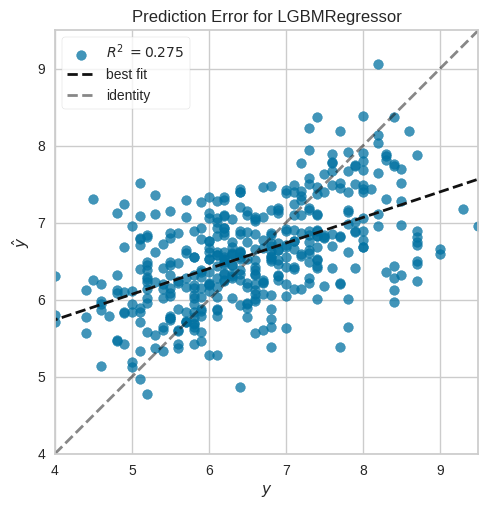

In [21]:
# First let's split out test and training set
# We need to stratify it so we have an equal distribution of affinity in our test as well as training set
# The test set will be 20% (0.2) of the full dataset
train, test = train_test_split(feat_all, test_size = 0.2)

# Let's select a regression technique
regressor = "lgbm"
model = get_regressor(regressor)

visualizer = prediction_error(model, train.drop("Affinity", axis = 1), train["Affinity"], test.drop("Affinity", axis = 1), test["Affinity"])

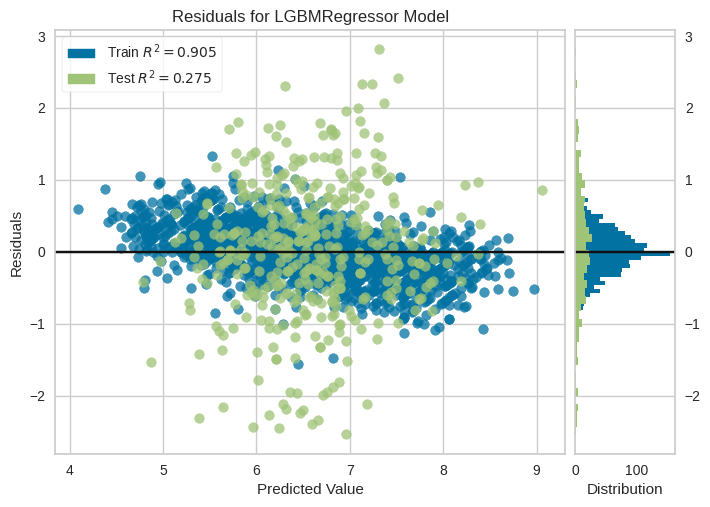

In [22]:

viz = residuals_plot(model, train.drop("Affinity", axis = 1), train["Affinity"], test.drop("Affinity", axis = 1), test["Affinity"], is_fitted=True)

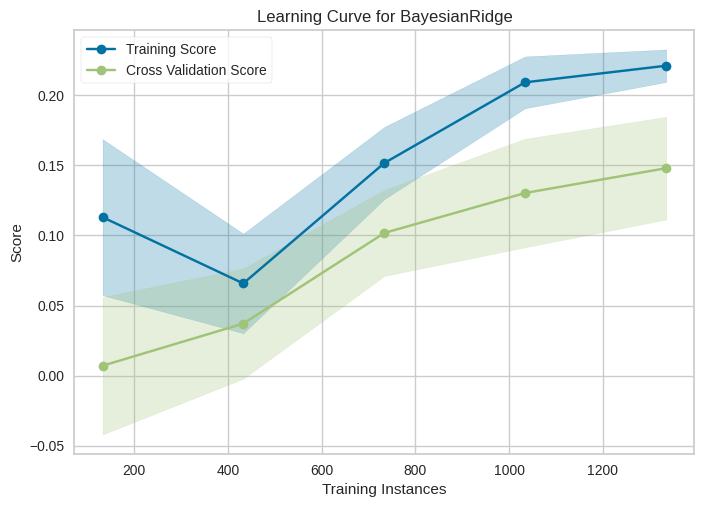

<Axes: title={'center': 'Learning Curve for BayesianRidge'}, xlabel='Training Instances', ylabel='Score'>

In [23]:
# Instantiate the regression model and visualizer
model = BayesianRidge()
visualizer = LearningCurve(model, scoring='r2')

# Fit the data to the visualizer
visualizer.fit(train.drop("Affinity", axis = 1), train["Affinity"])
visualizer.show()

In [25]:
# OPTIONAL space for YOUR CODE on feature selection
constant_cols = [col for col in feat_all.columns if feat_all[col].nunique() == 1] # col with only one value

scaled = (feat_all - feat_all.min()) / (feat_all.max() - feat_all.min()) # col per col normalization to 1

low_var = list(scaled.var()[scaled.var() < 0.01].index) # col with low var

low_var_only = [col for col in low_var if col not in constant_cols] # col with a low var

col_to_remove = constant_cols + low_var

print(len(feat_all.columns))
print(f"Colonnes constantes ({len(constant_cols)}) :\n", constant_cols, "\n")
print(f"Colonnes faible variance ({len(low_var_only)}) :\n", low_var_only)


192
Colonnes constantes (64) :
 ['PLPpartmetal', 'CHEMpartmetal', 'LYS9.A_VdWContact', 'ILE10.A_HBDonor', 'GLU12.A_Hydrophobic', 'GLU12.A_HBAcceptor', 'GLY13.A_HBDonor', 'TYR15.A_Hydrophobic', 'TYR15.A_HBDonor', 'TYR15.A_HBAcceptor', 'TYR15.A_CationPi', 'GLY16.A_HBDonor', 'GLY16.A_HBAcceptor', 'VAL17.A_HBDonor', 'VAL17.A_VdWContact', 'VAL29.A_VdWContact', 'ALA31.A_HBDonor', 'LEU32.A_HBDonor', 'LEU32.A_VdWContact', 'ILE35.A_Hydrophobic', 'ILE35.A_VdWContact', 'ILE52.A_Hydrophobic', 'ILE52.A_VdWContact', 'LEU55.A_Hydrophobic', 'LEU55.A_HBDonor', 'LEU55.A_VdWContact', 'LYS56.A_Hydrophobic', 'LYS56.A_VdWContact', 'LEU58.A_Hydrophobic', 'LEU58.A_VdWContact', 'ILE63.A_Hydrophobic', 'ILE63.A_VdWContact', 'VAL64.A_HBDonor', 'LYS65.A_Hydrophobic', 'LYS65.A_VdWContact', 'LEU66.A_HBAcceptor', 'LEU66.A_VdWContact', 'LEU78.A_Hydrophobic', 'LEU78.A_VdWContact', 'PHE82.A_CationPi', 'ASP86.A_HBAcceptor', 'LYS88.A_HBDonor', 'LYS88.A_HBAcceptor', 'LYS88.A_Anionic', 'LYS89.A_HBDonor', 'ASP92.A_HBDonor', 

<Axes: >

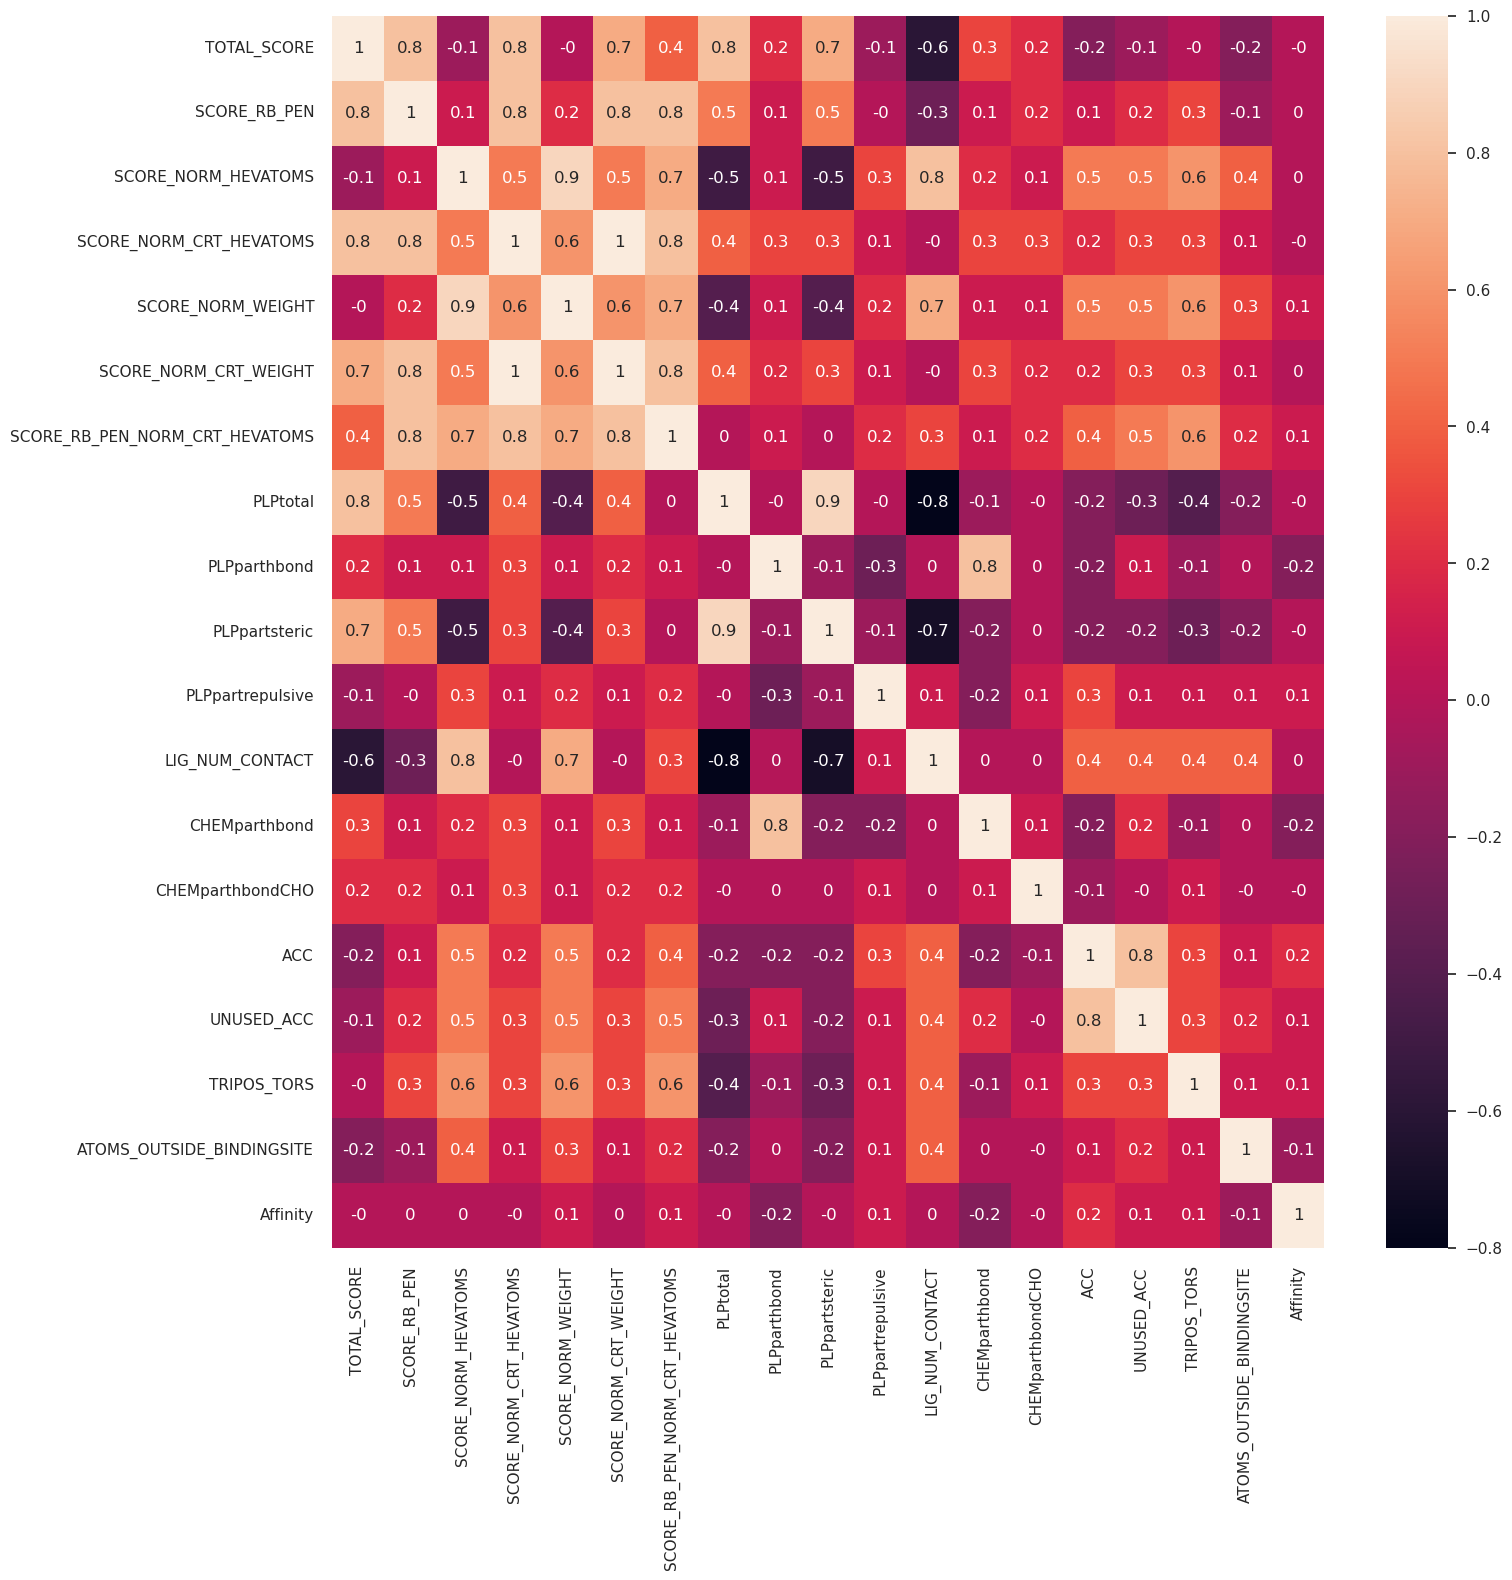

In [26]:
# Calculating the cross correlation between the different columns
# This is very easy since it's part of pandas!
fp_cols = [col for col in feat_all.columns if '.' in col]
col_to_remove += fp_cols

df_wo_ifp = feat_all.drop(columns = col_to_remove)
corr_matrix = df_wo_ifp.corr(method="spearman")
# Rounding the correlation to 1 digit to style the figure
corr_matrix = corr_matrix.round(1)

# Tweak some seaborn settings (size, font, style)
sns.set(rc={'figure.figsize':(16,16)})
sns.set(font_scale=1.5)
sns.set(style=None)

# Draw a correlation heatmap
sns.heatmap(corr_matrix, annot=True)



In [28]:
# no need to keep both col when they have a high correlation
high_corr = ["SCORE_NORM_HEVATOMS","SCORE_NORM_CRT_HEVATOMS","PLPtotal","PLPparthbond","UNUSED_ACC"]
high_corr

['SCORE_NORM_HEVATOMS',
 'SCORE_NORM_CRT_HEVATOMS',
 'PLPtotal',
 'PLPparthbond',
 'UNUSED_ACC']

### TOMORROW: Adding some additional features

Maybe merging structure-based features with molecular features will boost our model?
For example, molecular fingerprints, physicochemical properties etc.

MACCS fingerprints are used below.

In [24]:
chembl_df = pd.read_csv("smiles/chembl.smi",sep="\t", names=["SMILES","CPD_ID"], dtype="str")
chembl_df.dropna(inplace = True)

# Set the CPD_ID as rowID
chembl_df.index = chembl_df["CPD_ID"]
chembl_df.drop("CPD_ID", axis = 1, inplace = True)

chembl_df

,SMILES
CPD_ID,
CHEMBL100391|6.3,CN(C)CC(O)COc1ccc(Nc2ncc(Cl)c(Nc3ccccc3)n2)cc1
CHEMBL100664|4.8,COc1ccccc1Nc1ccnc(Nc2ccc(OCC(O)CN(C)C)cc2)n1
CHEMBL100675|4.7,Cc1ccc(Cl)c(Nc2cc(Nc3ccc(OCC(O)CN(C)C)cc3)ncn2)c1
CHEMBL100811|4.6,CN(C)CC(O)COc1ccc(Nc2cc(Nc3ccccc3Br)ncn2)cc1
CHEMBL100945|4.7,C#CCN(c1cc(Nc2ccc(OCC(O)CN(C)C)cc2)ncn1)c1cc(C...
...,...
CHEMBL99687|4.6,Cc1ccc(Nc2ccnc(Nc3ccc(OCC(O)CN(C)C)cc3)n2)cc1
CHEMBL99689|5.4,CN(C)CC(O)COc1ccc(Nc2nccc(Nc3ccccc3C#N)n2)cc1
CHEMBL99699|4.6,CC(C)c1ccccc1Nc1cc(Nc2ccc(OCC(O)CN(C)C)cc2)ncn1


In [ ]:
# Borrowed from https://github.com/DrrDom/rdkit-scripts/
from rdkit.Chem import rdMolDescriptors, QED, FindMolChiralCenters
from rdkit.Chem.Scaffolds.MurckoScaffold import GetScaffoldForMol
from multiprocessing import Pool, cpu_count
from itertools import combinations

# Count number of fused rings
def fused_ring_count(m):
    q = m.GetRingInfo()
    rings = [set(r) for r in q.AtomRings()]
    go_next = True
    while go_next:
        go_next = False
        for i, j in combinations(range(len(rings)), 2):
            if rings[i] & rings[j]:
                q = rings[i] | rings[j]
                del rings[j], rings[i]
                rings.append(q)
                go_next = True
                break
    return len(rings)

# Count number of unique hydrogen bonding atoms
HDonorSmarts = Chem.MolFromSmarts('[$([N;!H0;v3]),$([N;!H0;+1;v4]),$([O,S;H1;+0]),$([n;H1;+0])]')
HAcceptorSmarts = Chem.MolFromSmarts('[$([O,S;H1;v2]-[!$(*=[O,N,P,S])]),' +
                                     '$([O,S;H0;v2]),$([O,S;-]),$([N;v3;!$(N-*=!@[O,N,P,S])]),' +
                                     '$([nH0,o,s;+0])]')
def count_hbd_hba_atoms(m):
    HDonor = m.GetSubstructMatches(HDonorSmarts)
    HAcceptor = m.GetSubstructMatches(HAcceptorSmarts)
    return len(set(HDonor + HAcceptor))

def physchem_properties(smi):
    # Parse the molecule
    m = Chem.MolFromSmiles(smi)
    
    if m is not None:
        # Calculate all descriptors
        hba = rdMolDescriptors.CalcNumHBA(m)
        hbd = rdMolDescriptors.CalcNumHBD(m)
        nrings = rdMolDescriptors.CalcNumRings(m)
        rtb = rdMolDescriptors.CalcNumRotatableBonds(m)
        psa = rdMolDescriptors.CalcTPSA(m)
        logp, mr = rdMolDescriptors.CalcCrippenDescriptors(m)
        mw = rdMolDescriptors._CalcMolWt(m)
        csp3 = rdMolDescriptors.CalcFractionCSP3(m)
        hac = m.GetNumHeavyAtoms()
        if hac == 0:
            fmf = 0
        else:
            fmf = GetScaffoldForMol(m).GetNumHeavyAtoms() / hac
        qed = QED.qed(m)
        nrings_fused = fused_ring_count(m)
        n_unique_hba_hbd_atoms = count_hbd_hba_atoms(m)
        max_ring_size = len(max(m.GetRingInfo().AtomRings(), key=len, default=()))
        n_chiral_centers = len(FindMolChiralCenters(m, includeUnassigned=True))
        fcsp3_bm = rdMolDescriptors.CalcFractionCSP3(GetScaffoldForMol(m))
        
        # Return all calculated values
        return [hba, hbd, hba + hbd, nrings, rtb, round(psa, 2), round(logp, 2), round(mr, 2), round(mw, 2), \
               round(csp3, 3), round(fmf, 3), round(qed, 3), hac, nrings_fused, n_unique_hba_hbd_atoms, \
               max_ring_size, n_chiral_centers, round(fcsp3_bm, 3)]

In [ ]:
# Create a placeholder for the physicochemical properties
props = ["hba", "hbd", "hba + hbd", "nrings", "rtb", "psa", "logp", "mol_frac", "mol_weight", \
               "csp3-count", "fmf", "qed", "hac", "nrings_fused", "n_unique_hb_atoms", \
               "max_ring_size", "n_chiral_centers", "csp3_frac_bm"]

chembl_df[props] = 0.0
results = [] 
for index, row in chembl_df.iterrows():
    results.append(physchem_properties(row["SMILES"]))

chembl_df[props] = pd.DataFrame(results, index=chembl_df.index, columns=props)
chembl_df.head()

In [ ]:
# Creating a MACCS fingerprint calculator
# OTHER options: ecfp, fcfp, ecfp-count, fcfp-count
# ecfp - Extended Connectivity FingerPrint
# fcfp - Functional Class FingerPrint
# See https://molfeat.datamol.io/featurizers
calc = FPCalculator("maccs")

# Creating a transformer
trans = MoleculeTransformer(calc)

# Performing the calculating and storing the fingerprints
chembl_df['fp'] = trans.transform(chembl_df["SMILES"].values)

# Checking the results
chembl_df.head()

As you see, we now have the fingerprint in the "fp" column as an array. However, this is not something that we can directly use for machine learning. So we need to split the fingerprint into individual bits.

In [ ]:
# Let's calculate the length of the FP
fp_length = len(chembl_df['fp'][0])

# Create a column name for each bit
fp_names = [f"FP_{i}" for i in range(0,fp_length)]

# Now let's split that fingerprint
fingerprints = pd.DataFrame(chembl_df['fp'].to_list(), columns = fp_names, index = chembl_df.index)

# Drop the SMILES and FP column and merge the results
chembl_df.drop("SMILES", axis = 1, inplace = True)
chembl_df.drop("fp", axis = 1, inplace = True)
chembl_df = chembl_df.merge(fingerprints, left_index=True, right_index=True)

# Checking the results
chembl_df

Now we have all the molecular properties, so we can merge them with our existing dataset and rerun our training!

In [ ]:
feat_all = pd.merge(feat_all, chembl_df, left_index=True, right_index=True)
feat_all.head()

In [ ]:
# First let's split out test and training set
# We need to stratify it so we have an equal distribution of affinity in our test as well as training set
# The test set will be 20% (0.2) of the full dataset
train, test = train_test_split(feat_all, test_size = 0.2)

# Let's select a regression technique
regressor = "svr"
model = get_regressor(regressor)

visualizer = prediction_error(model, train.drop("Affinity", axis = 1), train["Affinity"], test.drop("Affinity", axis = 1), test["Affinity"])


In [ ]:
viz = residuals_plot(model, train.drop("Affinity", axis = 1), train["Affinity"], test.drop("Affinity", axis = 1), test["Affinity"], is_fitted=True)

### When we are happy with our model we can build the final one and do predictions

In [ ]:
# Select the best technique
final_model = get_regressor("lgbm")

# Train our final model on all our data not only a partial set
final_model.fit(feat_all.drop("Affinity", axis = 1), feat_all["Affinity"])

# FINAL PREDICTION

For the final steps, we have to prepare the 10K prospective dataset

In [ ]:
# Reading in the docking scores and ifp
prosp_feats_4nj3 = pd.read_csv("4nj3_docked/prospective_features.csv.gz")
prosp_ifps_4nj3 = pd.read_csv("4nj3_docked/prospective_ifp.csv.gz")
prosp_feats_5k4j = pd.read_csv("5k4j_docked/prospective_features.csv.gz")
prosp_ifps_5k4j = pd.read_csv("5k4j_docked/prospective_ifp.csv.gz")

# Reading and processing in the prospective compound smiles
prosp_df = pd.read_csv("smiles/prospective.smi",sep="\t", names=["SMILES","CPD_ID"], dtype="str")
prosp_df.dropna(inplace = True)
prosp_df.index = prosp_df["CPD_ID"]
prosp_df.drop("CPD_ID", axis = 1, inplace = True)

# Be sure to check the data

In [ ]:
# YOU: apply the same pose selection, calculations, feature filters, merges, transformations
# Optional fingerprints and physchem properties

# EXAMPLE BELOW

# Merging 4NJ3 docking + ifp
feat_final = prosp_feats_4nj3.merge(prosp_ifps_4nj3, left_index=True, right_index=True)

# POSE SELECTION based on SCORE_RB_PEN_NORM_CRT_HEVATOMS
feat_final.sort_values(by=["SCORE_RB_PEN_NORM_CRT_HEVATOMS"], inplace = True)
feat_final["CPD_ID"] = [row_id.split("_entry_")[0] for row_id in feat_final.index]
feat_final.drop_duplicates("CPD_ID", keep="first", inplace = True)

# Store the specific pose for now
feat_final["POSE"] = feat_final.index
feat_final.index = feat_final["CPD_ID"]
feat_final.drop("CPD_ID", axis = 1, inplace = True)

# CHECK RESULTS
feat_final

In [ ]:
# ADDING physicochemical properties
feat_final[props] = 0.0
results = [] 
for index, row in prosp_df.iterrows():
    results.append(physchem_properties(row["SMILES"]))

feat_final[props] = pd.DataFrame(results, index=prosp_df.index, columns=props)
feat_final.head()

In [ ]:
# ADDING molecular fingerprints
# Fingerprint calculation has been created earlier, so we can directly go to calculating and storing the fingerprints
prosp_df['fp'] = trans.transform(prosp_df["SMILES"].values)

# Parsing the fingerprint
# 1. split that fingerprint
fingerprints = pd.DataFrame(prosp_df['fp'].to_list(), columns = fp_names, index = prosp_df.index)
# 2. Drop the SMILES and FP column and merge the results
prosp_df.drop("SMILES", axis = 1, inplace = True)
prosp_df.drop("fp", axis = 1, inplace = True)
prosp_df = prosp_df.merge(fingerprints, left_index=True, right_index=True)

# Checking the results
prosp_df

In [ ]:
# Merge features and molecular fingerprint
feat_final = pd.merge(feat_final, prosp_df, left_index=True, right_index=True)

feat_final.columns.values

# USE the POSE as rowname again and remove that column
feat_final.index = feat_final["POSE"]
feat_final.drop(["POSE"], axis = 1, inplace = True)

# CHECK
feat_final

### READY FOR THE FINAL STEPS!

1. Predicting the affinity
2. Selecting the top hits
3. visualizing the top results

In [ ]:
# Predict the affinity 
predicted = final_model.predict(feat_final)

# Create dataframe
pred_df = pd.DataFrame(predicted, index=feat_final.index, columns=["PRED_AFFINITY"])

# Sort by descending predicted affinity
pred_df.sort_values(by=["PRED_AFFINITY"], ascending = False, inplace = True)

# Show the top 25
pred_df[:25]

### Final inspection and evaluation

A score only says so much, so let's also do a quick visual inspection and check if the docking pose is good or not.

For the prospective data the poses are hosted on the KLIFS website in the following format
https://klifs.net/ulla/<pdb>/<pose name>.sdf
    
So, for pose "KFL_6025917_entry_00135_conf_01" docked into 4NJ3 the pose is:
    https://klifs.net/ulla/4nj3/KFL_6025917_entry_00135_conf_01.sdf

In [ ]:
from urllib.request import urlopen
pose = "KFL_6025917_entry_00135_conf_01"
pose_url = f"https://klifs.net/ulla/4nj3/{pose}.sdf"

# Create a py3Dmol viewer
view = py3Dmol.view()

# Read the protein and show it as a slightly transparent gold cartoon
view.addModel(open("4nj3_docked/protein.pdb","r").read(), format="pdb")
prot = view.getModel()
prot.setStyle({"cartoon" : {"color" : "gold", "opacity": 0.6}})
prot.addMolData(open("4nj3_docked/ligand.pdb","r").read(), format="pdb")

### SELECTING the binding site residues within 5 angstrom of the ligand
pocket_selection = {"hetflag": True, "byres": "true", "expand": 5}

# Color the binding site residues in gold
view.addStyle(pocket_selection, {"stick" : {"colorscheme": "goldCarbon"}})

# Revert coloring of the ligand back to cyan
view.addStyle({"hetflag": True}, {"stick":{"colorscheme" : "cyanCarbon"}})

# THE DOCKING POSE - downloading and adding the docking pose
pose_data = urlopen(pose_url).read().decode('utf-8')
view.addModel(pose_data, format="mol")
pose = view.getModel()
pose.setStyle({"sticks" : {"colorscheme" : "grayCarbon"}})

# Zoom into the binding site and show it!
view.zoomTo(pocket_selection)
view.show()

# Structure-based regression project

**Author:** [Albert J. Kooistra](https://drug.ku.dk/staff/?pure=en/persons/612712), 2023-2025, University of Copenhagen


**Main steps in this notebook/for the project**
- Getting to know our target - CDK2 - structure and interactions
- Collecting our data
- Classification - how to select the most probable binding pose?
- Feature selection and combination
- Regression - predicting the binding affinity of the CDK2 inhibitors
- Evaluation
- Prospective application => searching for gold!

From the predicted compounds with the highest affinity select top 3 candidates and create a poster for the final session!

## Installation and import of libraries and functions

Simply execute the code cells below to get started. 
Note the pip install might give you some minor errors, but you can ignore these.

In [ ]:
# Installing missing libraries necessary for processing
!pip install -q rdkit prolif==1.1.0
!pip install -q py3Dmol

# Latest additions to process small molecules and calculate molecular features
!pip install -q datamol
!pip install -q molfeat

# Yellowbrick for visualizing Scikit-based machine learning models
!pip install -q yellowbrick

# Lightgbm and xgboost for gradient boosting
!pip install -q lightgbm
!pip install -q xgboost

In [ ]:
# Import packages and libraries
import matplotlib.pyplot as plt
import MDAnalysis as mda
import numpy as np
import os
import pandas as pd
import prolif as plf
import py3Dmol
import re
import seaborn as sns

from ipywidgets import interact,fixed,IntSlider
from math import ceil
from rdkit import Chem
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split
from prolif.plotting.network import LigNetwork
from rdkit import Geometry

# Latest additions
import datamol as dm
from molfeat.calc import FPCalculator
from molfeat.trans import MoleculeTransformer
from yellowbrick.regressor import prediction_error, residuals_plot
from yellowbrick.datasets import load_energy
from yellowbrick.model_selection import LearningCurve
from yellowbrick.regressor import PredictionError

In [ ]:
# Disabling warnings (can be tricky) - but RDkit can be "noisy"
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# HELPER FUNCTIONS
# No need to read the code or interpret

# Hover functions for the molecular viewer (Javascript code)
hover_func = """
  function(atom,viewer) {
    if (!atom.label) 
      atom.label = viewer.addLabel(atom.resn + " " + atom.resi,
      {position: atom, backgroundColor: 'black', fontColor:'white'});
  }"""

# Unhover function for the molecular viewer (Javascript code)
unhover_func = """function(atom,viewer) {if (atom.label) { viewer.removeLabel(atom.label); delete atom.label; }}"""

# proLIF - redefining HB-acceptors (slightly wider angle)
class HBAcceptor(plf.interactions.HBAcceptor):
   def __init__(self): 
     super().__init__(angles=(120, 180))

# proLIF - redefining HB-donors (slightly wider angle)
class HBDonor(plf.interactions.HBDonor):
   def __init__(self): 
      super().__init__(angles=(120, 180))

# Functions based on TeachOpenCADD - T007
# https://projects.volkamerlab.org/teachopencadd/index.html
def plot_roc_curves_for_models(score_column, data, save_png = False, negative_scores = True):
    """
    Helper function to plot customized roc curve.

    Parameters
    ----------
    score_column: string
        Name of the column with the scores
    data: dataframe
        Dataframe with two columns: <Score> and "Active"
    save_png: bool
        Save image to disk (default = False)
    negative_scores: bool
        Scores are inverted if lower scores are better

    Returns
    -------
    fig:
        Figure.
    """

    
    if negative_scores:
      data = data.copy()
      data[score_column] = -1 * data[score_column]

    fig, ax = plt.subplots()
    fig.set_dpi(100)

    # Compute ROC plot with False postive rate and True positive rate
    fpr, tpr, thresholds = roc_curve(data["Active"], data[score_column], pos_label=1)

    # Calculate Area under the curve to display on the plot
    auc = roc_auc_score(data["Active"], data[score_column])

    # Plot the computed values
    ax.plot(fpr, tpr, label=(f"{score_column} AUROC = {auc:.2f}"))

    # Custom settings for the plot
    ax.plot([0, 1], [0, 1], "r--")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("Receiver Operating Characteristic")
    ax.legend(loc="lower right")

    # Save plot
    if save_png:
        fig.savefig(f"{DATA}/roc_auc", dpi=300, bbox_inches="tight", transparent=True)

    return fig

# Based on example from https://gist.github.com/ravila4/
def EF_method2(actives_list, score_list, n_percent = 1, positive_scores = False):
    """ Calculates enrichment factor (method 2)
    Parameters:
    actives_list - binary array of active/decoy status
    score_list - array of experimental scores
    n_percent - a percentage (default 1%)
    positive_scores - set to True if a higher score is better (default False)
    """

    # Count active and inactive compounds
    total_actives = len(actives_list[actives_list == 1])
    total_inactives = len(actives_list) - total_actives

    # Sort scores, while keeping track of active/decoy status
    labeled_hits = sorted(zip(score_list, actives_list), reverse=positive_scores)

    # Get position (index) of the inactive compound at n_percent FP-rate
    num_fp = ceil(n_percent/100 * total_inactives)
    # Get positions all inactive compounds and select the num_fp one
    pos_fps = [i for i, labeled in enumerate(labeled_hits) if labeled[1] == 0][num_fp]

    # Get number of actives at this position
    identified_actives = sum([labeled[1] for labeled in labeled_hits[:num_fp]])

    # Calculate enrichment factor (TP-rate / FP-rate)
    ef = (identified_actives/total_actives) / (n_percent/100)
    return round(ef,2)

## Cyclin-dependent kinase 2

Our protein target for this project is *CDK2*, also known as *cyclin-dependent kinase 2* or *cell division protein kinase 2*.

CDK2 is a protein kinase that is critical for regulating cell cycle progression by complexing with and phosphorylation of key targets involved in the transition from G1 to S phase. In addition, it is involved in DNA replication, transcription, and repair. 

As input we have:
* Known binding modes and affinities of CDK2 inhibitors from >200 crystal structures
* Known experimentally determined binding affinities of >2K CDK2 inhibitors
* A set of >10K virtual compounds constructed using a kinase fragment library

### Collecting and processing the data

Below we will download the dataset and extract it.
The files will be in your Noteable home folder under *final_project*.

If you would like to download the files to your own computers you can do so here:
https://www.dropbox.com/s/4ajdpj63qhyur3m/Week_6_dataset.tgz?dl=0

In [ ]:
# Getting the full data package and extract
# Only do this if we don't already have it!
%cd ~/
if not os.path.isfile("final_project/Week_6_dataset.tgz"):
    ! mkdir final_project 2>/dev/null
    %cd ~/final_project
    
    # Downloading the dataset
    ! wget -q --show-progress "https://www.dropbox.com/s/4ajdpj63qhyur3m/Week_6_dataset.tgz?dl=1" -O Week_6_dataset.tgz
    
    # Extracting the dataset
    ! tar -xvzf Week_6_dataset.tgz 2>/dev/null
else:
    %cd ~/final_project

### The data

We have three folders: *4nj3_docked* and *5k4j_docked*, and a *smiles* folder.
In these folders we have the processed docking results for docking in the 4NJ3 and 5K4J structures.

Docking scoring results: 
* chembl_features.csv.gz - docking scores and features for the ChEMBL CDK2 inhibitors
* xrays_features.csv.gz - docking scores and features for the redocked CDK2 inhibitors from the crystal structures
* prospective_features.csv.gz - docking scores and features for the virtual compounds

Interaction fingerprint results:
* chembl_ifp.csv.gz - Interactions for the docking poses of the ChEMBL CDK2 inhibitors
* xrays_ifp.csv.gz - Interactions for the docking poses of the redocked CDK2 inhibitors from the crystal structures
* prospective_ifp.csv.gz - Interactions for the docking poses of the virtual compounds

The results from the redocking:
* xrays_rmsd.csv.gz - RMSD for each docking pose of the redocked ligands from the CDK2 crystal structures

The unprepared reference structures:
* protein.pdb - the CDK2 protein structure
* ligand.pdb - the ligand in the CDK2 structure

And finally in the smiles folder, we have the chemical structure for all of the compounds:
* chembl.smi - The compounds in the ChEMBL CDK2 dataset
* xrays.smi - The compounds in the CDK2 crystal structures we use for redocking and pose prediction
* prospective.smi - The virtual kinase compound library for prospective application at the end of the project

### Reading the docking scores and ifp from docking in the 4NJ3 protein structure

Check the contents of all dataframes to be sure everything is in order and familiarize yourself with the data.

In [ ]:
# Reading in the docking scores and ifp from docking the 4NJ3 protein structure
chembl_feats_4nj3 = pd.read_csv("4nj3_docked/chembl_features.csv.gz")
xrays_feats_4nj3 = pd.read_csv("4nj3_docked/xrays_features.csv.gz")
chembl_ifps_4nj3 = pd.read_csv("4nj3_docked/chembl_ifp.csv.gz")
xrays_ifps_4nj3 = pd.read_csv("4nj3_docked/xrays_ifp.csv.gz")
rmsd_4nj3 = pd.read_csv("4nj3_docked/xrays_rmsd.csv.gz")

In [ ]:
# TODO: CHECK THE DATA
rmsd_4nj3

### Reading the docking scores and ifp from docking in the 5K4J protein structure

Check the contents of all dataframes to be sure everything is in order and familiarize yourself with the data.

In [ ]:
# Reading in the docking scores and ifp from docking the 5K4J protein structure
chembl_feats_5k4j = pd.read_csv("5k4j_docked/chembl_features.csv.gz")
xrays_feats_5k4j = pd.read_csv("5k4j_docked/xrays_features.csv.gz")
chembl_ifps_5k4j = pd.read_csv("5k4j_docked/chembl_ifp.csv.gz")
xrays_ifps_5k4j = pd.read_csv("5k4j_docked/xrays_ifp.csv.gz")
rmsd_5k4j = pd.read_csv("5k4j_docked/xrays_rmsd.csv.gz")

In [ ]:
# TODO: CHECK THE DATA

## Structure inspection and protein-ligand interactions

Atomistic insights into the CDK2 protein targets and its inhibitors!

In [ ]:
# Create a py3Dmol viewer
view = py3Dmol.view()

# Read the protein and show it as a slightly transparent gold cartoon
view.addModel(open("4nj3_docked/protein.pdb","r").read(), format="pdb")
prot = view.getModel()
prot.setStyle({"cartoon" : {"color" : "gold", "opacity": 0.6}})

# Read the ligand file and add the ligand 
prot.addMolData(open("4nj3_docked/ligand.pdb","r").read(), format="pdb")

# Add a hover/unhover functions to get some information about the residues and atoms
view.setHoverable({}, True, hover_func, unhover_func)

### SELECTING the binding site residues within 5 angstrom of the ligand
pocket_selection = {"hetflag": True, "byres": "true", "expand": 5}

# Color the binding site residues in gold
view.addStyle(pocket_selection, {"stick" : {"colorscheme": "goldCarbon"}})

# Revert coloring of the ligand back to cyan
view.addStyle({"hetflag": True}, {"stick":{"colorscheme" : "cyanCarbon"}})

# Zoom into the binding site and show it!
view.zoomTo(pocket_selection)
view.show()

**TODO:**
* Adjust the files read above to read the 5k4j protein and ligand (instead of the 4NJ3)
* Execute the code and inspect the pocket and binding of the ligand to CDK2
* What are the main differences between the two structures?

## Classification step - selecting the right pose

A crucial step in assessing a docking is the selection of the right docking pose. Using information from >200 crystal structures we will try to optimize the pose selection here by creating a pose classifier.

**Steps**:
* Select optimal binding modes using the RMSD (precalculated)
* Evaluating the features from docking into the crystal structures
* OPTIONAL: extending with a classifier method from last weeks notebook

First we need to combine the features with the RMSD to get an accurate data set. Below is an example for solely the docking into the 4NJ3 structure.

**QUICK recap**

The features.csv file contains a several different docking scoring elements, i.e. different docking scoring features. A list from the PLANTS manual is listed below.

*	PLPparthbond: PLP hbond score
*	PLPpartsteric: PLP steric contact score
*	PLPpartmetal: PLP metal interaction score
*	PLPpartrepulsive: PLP donor/donor and acceptor/acceptor repulsion score
*	PLPpartburpolar: PLP buried polar atoms score (polar atoms occluded by nonpolar ones)
*	LIG_NUM_CLASH: number of ligand atoms with PLP score greater zero
*	LIG_NUM_CONTACT: number of ligand atoms with attractive PLP score
*	LIG_NUM_NO_CONTACT: number of ligand atoms with zero PLP score
*	CHEMpartmetal: CHEMSCORE metal interaction score
*	CHEMparthbond: CHEMSCORE hbond score
*	DON: number of ligand donor atoms
*	ACC: number of ligand acceptor atoms
*	UNUSED_DON: number of unpaired ligand donors
*	UNUSED_ACC: number of unpaired ligand acceptors
*	CHEMPLP_CLASH: intra-ligand clash score
*	TRIPOS_TORS: intra-ligand torsion score
*	INTRAPROT_CHEMPLP_PLP: intra-protein score (only calculated for flex. side-chains)
*	ATOMS_OUTSIDE_BINDINGSITE: number of ligand atoms outside binding site


In [ ]:
# DATA we read in earlier for 4NJ3
# xrays_feats_4nj3 - features from docking
# xrays_ifps_4nj3 - IFPs from the docking poses = pd.read_csv("5k4j_docked/xrays_ifp.csv.gz")
# rmsd_4nj3 - RMSDs for the dockign poses compared to the crystal structures

# Combining the features with the RMSD
merged_rmsd = xrays_feats_4nj3.merge(rmsd_4nj3, left_index=True, right_index=True)
merged_rmsd.head()

Currently, the RMSD is a numerical value - but we want to discern between good/bad.\
By using cutoffs for good and bad poses, we can convert this into a classification problem!

In the example below we assume that all poses predicted with an RMSD ≤ 2.5 are good and RMSD ≥ 4.0 are bad.

In [ ]:
# First we only keep values in the good and bad range (making a copy of the data)
pose_filtered = merged_rmsd[ (merged_rmsd["RMSD"] <= 2.5) | (merged_rmsd["RMSD"]>= 4.0) ].copy()
pose_filtered

In [ ]:
# Convert RMSD into Good/Bad
pose_filtered["RMSD"][pose_filtered["RMSD"] <= 2.5] = True
pose_filtered["RMSD"][pose_filtered["RMSD"] >= 4.0] = False

# Convert type also to boolean
pose_filtered["RMSD"] = pose_filtered["RMSD"].astype('bool')

pose_filtered

Now we have our data, and are ready to evaluate which feature best corrrelates with the correct pose selection!

In [ ]:
# Select names of the columns in our dataset
colnames = pose_filtered.columns.values.tolist()

# Remove "RMSD" from the names
colnames = colnames[ : -1]

# Loop over the column names in our dataset
for colname in colnames:
    # Check if the column has only positive numbers or not
    # This is to invert the evalution of the score if it only contains positive
    only_positive = (pose_filtered[colname] < 0).sum().sum() == 0
    
    # Assess predictive power of this column for pose selection using the AUROC
    if only_positive:
        auc = roc_auc_score(pose_filtered["RMSD"], pose_filtered[colname])
    else:
        auc = roc_auc_score(pose_filtered["RMSD"], -1 * pose_filtered[colname])
        
    # Also take the enrichment factor into account at 1% FP-rate
    ef1 = EF_method2(pose_filtered["RMSD"], pose_filtered[colname], 1, only_positive)
    print(f"{colname} has an AUROC of {round(auc,2)} and EF1 of {round(ef1,2)}")

As we can see above, the features are not doing so well. So this could be a point for optimization!
We also made an assumption based on the RMSD, but this also means we can have multiple "correct" poses per ligand. Something to consider

For now, we will just use the "SCORE_RB_PEN_NORM_CRT_HEVATOMS" for the pose selection and continue.

### Regression preparation

Preparing our data

In [ ]:
# In this example, we will continue with just the 4NJ3 results both IFP and docking features

feat_all = chembl_feats_4nj3.merge(chembl_ifps_4nj3, left_index=True, right_index=True)
feat_all

In [ ]:
# Now we will select 1 pose per compound based on the results from the pose selection

# 1. Sorting the dataframe by the values in the selected column
feat_all.sort_values(by=["SCORE_RB_PEN_NORM_CRT_HEVATOMS"], inplace = True)

# 2. Selecting the first occurrence of each compound ID - splitting by "_entry_"
feat_all["CPD_ID"] = [row_id.split("_entry_")[0] for row_id in feat_all.index]

# 3. Remove all rows except the first occurrence for each compound (the one with the lowest pose_selection)
feat_all.drop_duplicates("CPD_ID", keep="first", inplace = True)

# 4. Replace the row ID with the cpd ID
feat_all.index = feat_all["CPD_ID"]
feat_all.drop("CPD_ID", axis = 1, inplace = True)

feat_all

You might have already noticed that the compound IDs are a bit strange.\
This is because the affinity (-log converted) is stored as part of the compound ID.\
So let's extract them and give them their own column.

In [ ]:
# Extract binding affinity for CDK2
feat_all["Affinity"] = [float(row_id.split("|")[1]) for row_id in feat_all.index]
feat_all

### Feature selection

* What steps can you do to reduce the number of features at this point?
* What information could you reuse from last weeks notebooks?

In [ ]:
# OPTIONAL space for YOUR CODE

### REGRESSION steps

All data is ready and prepared! We have selected an individual pose per compound, so now it's time to create a training and test set and build a regression model

Some of the code is based on an entry from Pat Walters' blog: practical cheminformatics
http://practicalcheminformatics.blogspot.com/

First below a helper function to easily switch between regression models

In [ ]:
# Import regression models
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge, RidgeCV, LinearRegression, BayesianRidge, Lasso
from sklearn.svm import SVR, SVC


# This list is not exhaustive, but contains several models that you can try
def get_regressor(name):
    if name == "linear":
        return LinearRegression()
    elif name == "svr":
        return SVR()
    elif name == "ridge":
        return Ridge()
    elif name == "ridgecv":
        return RidgeCV()
    elif name == "bayesianridge":
        return BayesianRidge()
    elif name == "lgbm":
        return LGBMRegressor()
    elif name == "randomforest":
        return RandomForestRegressor()
    elif name == "xgb":
        return XGBRegressor()
    elif name == "histgradientboosting":
        return HistGradientBoostingRegressor()
    else:
        print("ERROR: No known model selected")

In [ ]:
# First let's split out test and training set
# We need to stratify it so we have an equal distribution of affinity in our test as well as training set
# The test set will be 20% (0.2) of the full dataset
train, test = train_test_split(feat_all, test_size = 0.2)

# Let's select a regression technique
regressor = "lgbm"
model = get_regressor(regressor)

visualizer = prediction_error(model, train.drop("Affinity", axis = 1), train["Affinity"], test.drop("Affinity", axis = 1), test["Affinity"])

In [ ]:

viz = residuals_plot(model, train.drop("Affinity", axis = 1), train["Affinity"], test.drop("Affinity", axis = 1), test["Affinity"], is_fitted=True)

In [ ]:
# Instantiate the regression model and visualizer
model = BayesianRidge()
visualizer = LearningCurve(model, scoring='r2')

# Fit the data to the visualizer
visualizer.fit(train.drop("Affinity", axis = 1), train["Affinity"])
visualizer.show()

### TOMORROW: Adding some additional features

Maybe merging structure-based features with molecular features will boost our model?
For example, molecular fingerprints, physicochemical properties etc.

MACCS fingerprints are used below.

In [ ]:
chembl_df = pd.read_csv("smiles/chembl.smi",sep="\t", names=["SMILES","CPD_ID"], dtype="str")
chembl_df.dropna(inplace = True)

# Set the CPD_ID as rowID
chembl_df.index = chembl_df["CPD_ID"]
chembl_df.drop("CPD_ID", axis = 1, inplace = True)

chembl_df

In [ ]:
# Borrowed from https://github.com/DrrDom/rdkit-scripts/
from rdkit.Chem import rdMolDescriptors, QED, FindMolChiralCenters
from rdkit.Chem.Scaffolds.MurckoScaffold import GetScaffoldForMol
from multiprocessing import Pool, cpu_count
from itertools import combinations

# Count number of fused rings
def fused_ring_count(m):
    q = m.GetRingInfo()
    rings = [set(r) for r in q.AtomRings()]
    go_next = True
    while go_next:
        go_next = False
        for i, j in combinations(range(len(rings)), 2):
            if rings[i] & rings[j]:
                q = rings[i] | rings[j]
                del rings[j], rings[i]
                rings.append(q)
                go_next = True
                break
    return len(rings)

# Count number of unique hydrogen bonding atoms
HDonorSmarts = Chem.MolFromSmarts('[$([N;!H0;v3]),$([N;!H0;+1;v4]),$([O,S;H1;+0]),$([n;H1;+0])]')
HAcceptorSmarts = Chem.MolFromSmarts('[$([O,S;H1;v2]-[!$(*=[O,N,P,S])]),' +
                                     '$([O,S;H0;v2]),$([O,S;-]),$([N;v3;!$(N-*=!@[O,N,P,S])]),' +
                                     '$([nH0,o,s;+0])]')
def count_hbd_hba_atoms(m):
    HDonor = m.GetSubstructMatches(HDonorSmarts)
    HAcceptor = m.GetSubstructMatches(HAcceptorSmarts)
    return len(set(HDonor + HAcceptor))

def physchem_properties(smi):
    # Parse the molecule
    m = Chem.MolFromSmiles(smi)
    
    if m is not None:
        # Calculate all descriptors
        hba = rdMolDescriptors.CalcNumHBA(m)
        hbd = rdMolDescriptors.CalcNumHBD(m)
        nrings = rdMolDescriptors.CalcNumRings(m)
        rtb = rdMolDescriptors.CalcNumRotatableBonds(m)
        psa = rdMolDescriptors.CalcTPSA(m)
        logp, mr = rdMolDescriptors.CalcCrippenDescriptors(m)
        mw = rdMolDescriptors._CalcMolWt(m)
        csp3 = rdMolDescriptors.CalcFractionCSP3(m)
        hac = m.GetNumHeavyAtoms()
        if hac == 0:
            fmf = 0
        else:
            fmf = GetScaffoldForMol(m).GetNumHeavyAtoms() / hac
        qed = QED.qed(m)
        nrings_fused = fused_ring_count(m)
        n_unique_hba_hbd_atoms = count_hbd_hba_atoms(m)
        max_ring_size = len(max(m.GetRingInfo().AtomRings(), key=len, default=()))
        n_chiral_centers = len(FindMolChiralCenters(m, includeUnassigned=True))
        fcsp3_bm = rdMolDescriptors.CalcFractionCSP3(GetScaffoldForMol(m))
        
        # Return all calculated values
        return [hba, hbd, hba + hbd, nrings, rtb, round(psa, 2), round(logp, 2), round(mr, 2), round(mw, 2), \
               round(csp3, 3), round(fmf, 3), round(qed, 3), hac, nrings_fused, n_unique_hba_hbd_atoms, \
               max_ring_size, n_chiral_centers, round(fcsp3_bm, 3)]

In [ ]:
# Create a placeholder for the physicochemical properties
props = ["hba", "hbd", "hba + hbd", "nrings", "rtb", "psa", "logp", "mol_frac", "mol_weight", \
               "csp3-count", "fmf", "qed", "hac", "nrings_fused", "n_unique_hb_atoms", \
               "max_ring_size", "n_chiral_centers", "csp3_frac_bm"]

chembl_df[props] = 0.0
results = [] 
for index, row in chembl_df.iterrows():
    results.append(physchem_properties(row["SMILES"]))

chembl_df[props] = pd.DataFrame(results, index=chembl_df.index, columns=props)
chembl_df.head()

In [ ]:
# Creating a MACCS fingerprint calculator
# OTHER options: ecfp, fcfp, ecfp-count, fcfp-count
# ecfp - Extended Connectivity FingerPrint
# fcfp - Functional Class FingerPrint
# See https://molfeat.datamol.io/featurizers
calc = FPCalculator("maccs")

# Creating a transformer
trans = MoleculeTransformer(calc)

# Performing the calculating and storing the fingerprints
chembl_df['fp'] = trans.transform(chembl_df["SMILES"].values)

# Checking the results
chembl_df.head()

As you see, we now have the fingerprint in the "fp" column as an array. However, this is not something that we can directly use for machine learning. So we need to split the fingerprint into individual bits.

In [ ]:
# Let's calculate the length of the FP
fp_length = len(chembl_df['fp'][0])

# Create a column name for each bit
fp_names = [f"FP_{i}" for i in range(0,fp_length)]

# Now let's split that fingerprint
fingerprints = pd.DataFrame(chembl_df['fp'].to_list(), columns = fp_names, index = chembl_df.index)

# Drop the SMILES and FP column and merge the results
chembl_df.drop("SMILES", axis = 1, inplace = True)
chembl_df.drop("fp", axis = 1, inplace = True)
chembl_df = chembl_df.merge(fingerprints, left_index=True, right_index=True)

# Checking the results
chembl_df

Now we have all the molecular properties, so we can merge them with our existing dataset and rerun our training!

In [ ]:
feat_all = pd.merge(feat_all, chembl_df, left_index=True, right_index=True)
feat_all.head()

In [ ]:
# First let's split out test and training set
# We need to stratify it so we have an equal distribution of affinity in our test as well as training set
# The test set will be 20% (0.2) of the full dataset
train, test = train_test_split(feat_all, test_size = 0.2)

# Let's select a regression technique
regressor = "svr"
model = get_regressor(regressor)

visualizer = prediction_error(model, train.drop("Affinity", axis = 1), train["Affinity"], test.drop("Affinity", axis = 1), test["Affinity"])


In [ ]:
viz = residuals_plot(model, train.drop("Affinity", axis = 1), train["Affinity"], test.drop("Affinity", axis = 1), test["Affinity"], is_fitted=True)

### When we are happy with our model we can build the final one and do predictions

In [ ]:
# Select the best technique
final_model = get_regressor("lgbm")

# Train our final model on all our data not only a partial set
final_model.fit(feat_all.drop("Affinity", axis = 1), feat_all["Affinity"])

# FINAL PREDICTION

For the final steps, we have to prepare the 10K prospective dataset

In [ ]:
# Reading in the docking scores and ifp
prosp_feats_4nj3 = pd.read_csv("4nj3_docked/prospective_features.csv.gz")
prosp_ifps_4nj3 = pd.read_csv("4nj3_docked/prospective_ifp.csv.gz")
prosp_feats_5k4j = pd.read_csv("5k4j_docked/prospective_features.csv.gz")
prosp_ifps_5k4j = pd.read_csv("5k4j_docked/prospective_ifp.csv.gz")

# Reading and processing in the prospective compound smiles
prosp_df = pd.read_csv("smiles/prospective.smi",sep="\t", names=["SMILES","CPD_ID"], dtype="str")
prosp_df.dropna(inplace = True)
prosp_df.index = prosp_df["CPD_ID"]
prosp_df.drop("CPD_ID", axis = 1, inplace = True)

# Be sure to check the data

In [ ]:
# YOU: apply the same pose selection, calculations, feature filters, merges, transformations
# Optional fingerprints and physchem properties

# EXAMPLE BELOW

# Merging 4NJ3 docking + ifp
feat_final = prosp_feats_4nj3.merge(prosp_ifps_4nj3, left_index=True, right_index=True)

# POSE SELECTION based on SCORE_RB_PEN_NORM_CRT_HEVATOMS
feat_final.sort_values(by=["SCORE_RB_PEN_NORM_CRT_HEVATOMS"], inplace = True)
feat_final["CPD_ID"] = [row_id.split("_entry_")[0] for row_id in feat_final.index]
feat_final.drop_duplicates("CPD_ID", keep="first", inplace = True)

# Store the specific pose for now
feat_final["POSE"] = feat_final.index
feat_final.index = feat_final["CPD_ID"]
feat_final.drop("CPD_ID", axis = 1, inplace = True)

# CHECK RESULTS
feat_final

In [ ]:
# ADDING physicochemical properties
feat_final[props] = 0.0
results = [] 
for index, row in prosp_df.iterrows():
    results.append(physchem_properties(row["SMILES"]))

feat_final[props] = pd.DataFrame(results, index=prosp_df.index, columns=props)
feat_final.head()

In [ ]:
# ADDING molecular fingerprints
# Fingerprint calculation has been created earlier, so we can directly go to calculating and storing the fingerprints
prosp_df['fp'] = trans.transform(prosp_df["SMILES"].values)

# Parsing the fingerprint
# 1. split that fingerprint
fingerprints = pd.DataFrame(prosp_df['fp'].to_list(), columns = fp_names, index = prosp_df.index)
# 2. Drop the SMILES and FP column and merge the results
prosp_df.drop("SMILES", axis = 1, inplace = True)
prosp_df.drop("fp", axis = 1, inplace = True)
prosp_df = prosp_df.merge(fingerprints, left_index=True, right_index=True)

# Checking the results
prosp_df

In [ ]:
# Merge features and molecular fingerprint
feat_final = pd.merge(feat_final, prosp_df, left_index=True, right_index=True)

feat_final.columns.values

# USE the POSE as rowname again and remove that column
feat_final.index = feat_final["POSE"]
feat_final.drop(["POSE"], axis = 1, inplace = True)

# CHECK
feat_final

### READY FOR THE FINAL STEPS!

1. Predicting the affinity
2. Selecting the top hits
3. visualizing the top results

In [ ]:
# Predict the affinity 
predicted = final_model.predict(feat_final)

# Create dataframe
pred_df = pd.DataFrame(predicted, index=feat_final.index, columns=["PRED_AFFINITY"])

# Sort by descending predicted affinity
pred_df.sort_values(by=["PRED_AFFINITY"], ascending = False, inplace = True)

# Show the top 25
pred_df[:25]

### Final inspection and evaluation

A score only says so much, so let's also do a quick visual inspection and check if the docking pose is good or not.

For the prospective data the poses are hosted on the KLIFS website in the following format
https://klifs.net/ulla/<pdb>/<pose name>.sdf
    
So, for pose "KFL_6025917_entry_00135_conf_01" docked into 4NJ3 the pose is:
    https://klifs.net/ulla/4nj3/KFL_6025917_entry_00135_conf_01.sdf

In [ ]:
from urllib.request import urlopen
pose = "KFL_6025917_entry_00135_conf_01"
pose_url = f"https://klifs.net/ulla/4nj3/{pose}.sdf"

# Create a py3Dmol viewer
view = py3Dmol.view()

# Read the protein and show it as a slightly transparent gold cartoon
view.addModel(open("4nj3_docked/protein.pdb","r").read(), format="pdb")
prot = view.getModel()
prot.setStyle({"cartoon" : {"color" : "gold", "opacity": 0.6}})
prot.addMolData(open("4nj3_docked/ligand.pdb","r").read(), format="pdb")

### SELECTING the binding site residues within 5 angstrom of the ligand
pocket_selection = {"hetflag": True, "byres": "true", "expand": 5}

# Color the binding site residues in gold
view.addStyle(pocket_selection, {"stick" : {"colorscheme": "goldCarbon"}})

# Revert coloring of the ligand back to cyan
view.addStyle({"hetflag": True}, {"stick":{"colorscheme" : "cyanCarbon"}})

# THE DOCKING POSE - downloading and adding the docking pose
pose_data = urlopen(pose_url).read().decode('utf-8')
view.addModel(pose_data, format="mol")
pose = view.getModel()
pose.setStyle({"sticks" : {"colorscheme" : "grayCarbon"}})

# Zoom into the binding site and show it!
view.zoomTo(pocket_selection)
view.show()